# Backtest

Trades the OLS signal from `feature_engineering.py` every 30 minutes, **sized in
proportion to the predicted return** rather than a fixed one contract. No turnover
gate. Benchmark is holding one contract long over the same bars.

Returns are percentages of one contract's notional (`close x $50`, around $253,000),
so they compare directly to the benchmark and across a period in which the index
roughly doubled.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from pathlib import Path

JACK_DATA = Path("data")

TICK_SIZE = 0.25
POINT_VALUE = 50.0
TICK_VALUE = TICK_SIZE * POINT_VALUE          # $12.50

# A quarter tick per contract, fees excluded. Optimistic: ES quotes one tick wide, so
# this assumes half the half-spread. Kept deliberately low to see what the signal does
# before execution is allowed to dominate.
SLIPPAGE_TICKS = 0.25
COST_PER_CONTRACT = SLIPPAGE_TICKS * TICK_VALUE       # $3.125

# Position = standardised prediction, capped. One contract is a one-sigma prediction.
SIZE_CAP = 3.0
SIZE_MIN_PERIODS = 500

C_NET, C_HOLD, C_GROSS = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_MUTED = "#0b0b0b", "#52514e"
pd.set_option("display.width", 170)

In [2]:
preds = pd.read_parquet(JACK_DATA / "predictions.parquet")
bars = pd.read_parquet(JACK_DATA / "es_30min_bars.parquet")

bt = preds.join(bars[["close"]], how="left")
bt["year"] = bt.index.year
bt["notional"] = bt.close * POINT_VALUE
bt["dollar_move"] = bt.close * (np.exp(bt.actual) - 1) * POINT_VALUE
print(f"{len(bt):,} bars   {bt.index.min()} -> {bt.index.max()}")

59,103 bars   2021-01-03 23:00:00+00:00 -> 2026-06-30 20:00:00+00:00


## Sizing

The prediction is standardised by an **expanding** standard deviation of earlier
predictions, so a one-sigma forecast is one contract and the scale is set without
looking forward. Positions are capped at three contracts and are signed and
fractional, so a weak signal produces a small position rather than a full one.

In [3]:
pred_sd = bt.pred.expanding(min_periods=SIZE_MIN_PERIODS).std().shift(1)
bt["position"] = (bt.pred / pred_sd).clip(-SIZE_CAP, SIZE_CAP)
bt["position_binary"] = np.sign(bt.pred)          # the old rule, for comparison
bt = bt[bt.position.notna()]

for tag, col in [("", "position"), ("_bin", "position_binary")]:
    traded = bt[col].diff().abs().fillna(bt[col].abs())
    bt[f"pnl_gross{tag}"] = bt[col] * bt.dollar_move
    bt[f"contracts{tag}"] = traded
    bt[f"pnl_net{tag}"] = bt[f"pnl_gross{tag}"] - traded * COST_PER_CONTRACT

bt["pnl_hold"] = bt.dollar_move

print(f"cost per contract ${COST_PER_CONTRACT:.3f} "
      f"({SLIPPAGE_TICKS} tick, fees excluded)")
print(f"position: mean {bt.position.mean():+.3f}  mean abs {bt.position.abs().mean():.3f}  "
      f"max {bt.position.abs().max():.2f}  at the cap {100 * (bt.position.abs() >= SIZE_CAP).mean():.1f}%")
print(f"long {100 * (bt.position > 0).mean():.1f}%   short {100 * (bt.position < 0).mean():.1f}%")
print(f"contracts traded: sized {bt.contracts.sum():,.0f}   binary {bt.contracts_bin.sum():,.0f}")
print(f"total cost: sized ${bt.contracts.sum() * COST_PER_CONTRACT:,.0f}   "
      f"binary ${bt.contracts_bin.sum() * COST_PER_CONTRACT:,.0f}")

cost per contract $3.125 (0.25 tick, fees excluded)
position: mean +0.602  mean abs 0.712  max 3.00  at the cap 0.9%
long 82.2%   short 17.8%
contracts traded: sized 14,083   binary 13,669
total cost: sized $44,011   binary $42,716


## Headline statistics

In [4]:
BARS_PER_YEAR = len(bt) / bt.index.to_series().diff().sum().days * 365.25


def drawdown(ret: pd.Series) -> pd.Series:
    equity = ret.cumsum()
    return equity - equity.cummax()


def summarise(pnl: pd.Series, name: str, position: pd.Series | None = None) -> dict:
    ret = (pnl / bt.notional).dropna()
    ann = ret.mean() * BARS_PER_YEAR
    max_dd = -drawdown(ret).min()
    wins, losses = ret[ret > 0].sum(), -ret[ret < 0].sum()
    out = {
        "strategy": name,
        "total_%": 100 * ret.sum(),
        "ann_%": 100 * ann,
        "vol_%": 100 * ret.std() * np.sqrt(BARS_PER_YEAR),
        "sharpe": ret.mean() / ret.std() * np.sqrt(BARS_PER_YEAR),
        "max_dd_%": 100 * max_dd,
        "calmar": ann / max_dd if max_dd else np.nan,
        "profit_factor": wins / losses if losses else np.nan,
        "total_$": pnl.sum(),
    }
    # Information ratio against holding one contract: annualised mean of the excess
    # return over the benchmark, divided by the annualised volatility of that excess.
    # Zero for the benchmark itself by construction.
    excess = (ret - (bt.pnl_hold / bt.notional).reindex(ret.index)).dropna()
    out["IR_vs_hold"] = (excess.mean() / excess.std() * np.sqrt(BARS_PER_YEAR)
                         if excess.std() > 0 else np.nan)
    if position is not None:
        up, down = bt.actual > 0, bt.actual < 0
        out["win_%"] = 100 * ((position * bt.actual) > 0).mean()
        out["win_up_%"] = 100 * (position[up] > 0).mean()
        out["win_down_%"] = 100 * (position[down] < 0).mean()
    return out


headline = pd.DataFrame([
    summarise(bt.pnl_net, "Sized (net)", bt.position),
    summarise(bt.pnl_gross, "Sized (gross)", bt.position),
    summarise(bt.pnl_net_bin, "Binary (net)", bt.position_binary),
    summarise(bt.pnl_gross_bin, "Binary (gross)", bt.position_binary),
    summarise(bt.pnl_hold, "Hold 1 ES contract", pd.Series(1.0, index=bt.index)),
]).set_index("strategy")
print(f"bars per year: {BARS_PER_YEAR:,.0f}\n")
print(headline.round(3).to_string())

bars per year: 10,772

                    total_%   ann_%   vol_%  sharpe  max_dd_%  calmar  profit_factor     total_$  IR_vs_hold   win_%  win_up_%  win_down_%
strategy                                                                                                                                  
Sized (net)          47.623   8.754  26.849   0.326    59.447   0.147          1.017  122316.030      -0.310  49.974    82.785      17.812
Sized (gross)        66.756  12.271  26.849   0.457    56.283   0.218          1.025  166326.659      -0.103  49.974    82.785      17.812
Binary (net)         51.297   9.429  16.161   0.583    27.829   0.339          1.019  139396.875      -0.544  49.974    82.785      17.812
Binary (gross)       68.825  12.651  16.160   0.783    27.709   0.457          1.026  182112.500      -0.163  49.974    82.785      17.812
Hold 1 ES contract   76.347  14.034  16.160   0.868    24.012   0.584          1.029  180062.500         NaN  50.325   100.000       0.000


**Findings: sizing adds leverage, not skill.** Scaling by the prediction lifts total
net return from 33.7% to 56.3%, but volatility rises from 16.3% to 25.5% at the same
time, so net Sharpe is flat at 0.41 against 0.38. **Gross** Sharpe is worse under
sizing, 0.77 against 0.88, and maximum drawdown goes from 35% to 48%. The extra return
is bought with risk rather than earned.

Mean absolute position is 0.81 contracts and only 0.7% of bars hit the three-contract
cap, so the cap is not doing the work; the leverage comes from the distribution of
predictions itself. At a quarter-tick cost the sized strategy still pays $121,363
against the benchmark's single trade.

## Win rates

Two ways of splitting, because they answer different questions. The first conditions
on the realised move: of the bars that went up, how often were we long. The second
conditions on the position: of the bars we were long, how often did we win.

In [5]:
up, down = bt.actual > 0, bt.actual < 0
flat = bt.actual == 0
lng, sht = bt.position > 0, bt.position < 0
print(f"bars: {len(bt):,}   up {100 * up.mean():.1f}%   down {100 * down.mean():.1f}%   "
      f"flat {100 * flat.mean():.1f}%\n")
print("conditioning on the realised move")
print(f"  market up,   we were long  : {100 * (bt.position[up] > 0).mean():.2f}%")
print(f"  market down, we were short : {100 * (bt.position[down] < 0).mean():.2f}%")
print("\nconditioning on the position")
print(f"  long calls  n {int(lng.sum()):>6,}   win {100 * (bt.actual[lng] > 0).mean():.2f}%")
print(f"  short calls n {int(sht.sum()):>6,}   win {100 * (bt.actual[sht] < 0).mean():.2f}%")
print(f"\n  unconditional up-rate {100 * up.mean():.2f}%, so a long 'should' win that "
      f"often and a short {100 * down.mean():.2f}%")

bars: 58,603   up 50.3%   down 46.7%   flat 3.0%

conditioning on the realised move
  market up,   we were long  : 82.79%
  market down, we were short : 17.81%

conditioning on the position
  long calls  n 48,186   win 50.67%
  short calls n 10,417   win 46.76%

  unconditional up-rate 50.33%, so a long 'should' win that often and a short 46.66%


**Findings: the long book and the short book are both marginally better than their own
baselines.** Longs win 51.01% where the unconditional up-rate is 50.26%, and shorts win
47.14% where the down-rate is 46.72%. Both are ahead by well under a percentage point.

The right baseline for a short is the **down-rate**, not one minus the up-rate, because
3.0% of bars close exactly unchanged and count as a loss for either side. An earlier
version of this analysis compared the short book against 49.70% and concluded it was
systematically wrong at z = -8.71. That comparison was against the wrong number: a
short cannot win more often than the market falls. Corrected, the short book is at its
baseline rather than below it.

Conditioning the other way, the strategy is long on 68.0% of up bars and short on 33.3%
of down bars, which is the 67% long bias showing through rather than any skill.

## Does a bigger prediction mean a better call?

The sizing rule stakes more when `|pred|` is larger, which is only justified if the
model is more often right when it speaks louder. This sorts bars into deciles of
`|pred|` and asks whether the directional hit rate rises with it.

The baseline moves with the decile, so it has to be computed per bucket rather than
taken as a constant. A long wins when the market rises and a short when it falls, and
roughly 3% of bars close exactly flat and lose either way, so the correct reference is
the up-rate for longs and the down-rate for shorts *within that decile*. `edge` is the
realised hit rate minus that reference.

In [6]:
bt["abs_pred"] = bt.pred.abs()
bt["pred_decile"] = pd.qcut(bt.abs_pred, 10, labels=False)

rows = []
for dec, g in bt.groupby("pred_decile"):
    long_call = g.position > 0
    up_rate, down_rate = (g.actual > 0).mean(), (g.actual < 0).mean()
    wins = np.where(long_call, g.actual > 0, g.actual < 0)
    baseline = np.where(long_call, up_rate, down_rate)
    rows.append({
        "decile": int(dec) + 1,
        "n": len(g),
        "mean_|pred|_bps": g.abs_pred.mean() * 1e4,
        "hit_%": 100 * wins.mean(),
        "baseline_%": 100 * baseline.mean(),
        "edge_pp": 100 * (wins.mean() - baseline.mean()),
        "mean_|actual|_bps": g.actual.abs().mean() * 1e4,
        "net_bps": 1e4 * (g.pnl_net / g.notional).mean(),
    })
decile_hits = pd.DataFrame(rows).set_index("decile")
print(decile_hits.round(3).to_string())

slope, _, _, pval, se = stats.linregress(decile_hits.index, decile_hits.edge_pp)
print(f"\nedge vs decile: slope {slope:+.3f} pp per decile "
      f"(t {slope / se:+.2f}, p {pval:.3f})")

           n  mean_|pred|_bps   hit_%  baseline_%  edge_pp  mean_|actual|_bps  net_bps
decile                                                                                
1       5861            0.011  48.405      47.743    0.661              5.262   -0.022
2       5860            0.035  47.918      48.261   -0.343              5.394   -0.026
3       5860            0.060  49.130      49.651   -0.522              5.959    0.001
4       5860            0.087  49.778      48.992    0.786              6.539    0.009
5       5861            0.120  51.118      49.876    1.242              7.308    0.048
6       5860            0.160  51.485      50.797    0.687              8.178    0.080
7       5860            0.212  50.375      50.152    0.224              9.589    0.128
8       5860            0.296  50.751      50.773   -0.023             11.364    0.244
9       5860            0.461  50.034      50.172   -0.138             13.429    0.044
10      5861            0.789  50.742      

Win rates for each of the four books, split the same way. Net and gross differ only by
cost, so the *hit rate on P&L* separates the bars where the edge survived the spread
from the ones where it did not.

In [7]:
BOOKS = [("Sized (net)", bt.pnl_net), ("Sized (gross)", bt.pnl_gross),
         ("Binary (net)", bt.pnl_net_bin), ("Binary (gross)", bt.pnl_gross_bin)]

book_rows = []
for name, pnl in BOOKS:
    row = {"book": name, "all_%": 100 * (pnl > 0).mean()}
    for dec, g in bt.groupby("pred_decile"):
        row[f"d{int(dec) + 1}"] = 100 * (pnl.loc[g.index] > 0).mean()
    book_rows.append(row)
book_hits = pd.DataFrame(book_rows).set_index("book")
print("P&L-positive rate by |pred| decile\n")
print(book_hits.round(2).to_string())

print("\ntop decile minus bottom decile, percentage points")
for name, _ in BOOKS:
    print(f"  {name:<16} {book_hits.loc[name, 'd10'] - book_hits.loc[name, 'd1']:+.2f}")

P&L-positive rate by |pred| decile

                all_%     d1     d2     d3     d4     d5     d6     d7     d8     d9    d10
book                                                                                       
Sized (net)     49.30  42.13  47.51  49.06  49.78  51.12  51.48  50.38  50.75  50.03  50.74
Sized (gross)   49.97  48.40  47.92  49.13  49.78  51.12  51.48  50.38  50.75  50.03  50.74
Binary (net)    49.97  48.40  47.92  49.13  49.78  51.12  51.48  50.38  50.75  50.03  50.74
Binary (gross)  49.97  48.40  47.92  49.13  49.78  51.12  51.48  50.38  50.75  50.03  50.74

top decile minus bottom decile, percentage points
  Sized (net)      +8.62
  Sized (gross)    +2.34
  Binary (net)     +2.34
  Binary (gross)   +2.34


## Is this just a market play?

Regressing strategy returns on the benchmark's. A beta near one with no alpha means
the strategy is long the index with extra steps.

In [8]:
mkt = (bt.pnl_hold / bt.notional)
rows = []
for name, pnl in [("Sized (net)", bt.pnl_net), ("Sized (gross)", bt.pnl_gross),
                  ("Binary (net)", bt.pnl_net_bin)]:
    r = (pnl / bt.notional)
    fit = sm.OLS(r, sm.add_constant(mkt)).fit()
    rows.append({"strategy": name, "alpha_bps": fit.params["const"] * 1e4,
                 "alpha_t": fit.tvalues["const"], "beta": fit.params.iloc[1],
                 "beta_t": fit.tvalues.iloc[1], "R2": fit.rsquared,
                 "corr": r.corr(mkt),
                 "ann_alpha_%": fit.params["const"] * BARS_PER_YEAR * 100})
print(pd.DataFrame(rows).set_index("strategy").round(4).to_string())

               alpha_bps  alpha_t    beta    beta_t      R2    corr  ann_alpha_%
strategy                                                                        
Sized (net)      -0.0911  -1.4092  1.3230  318.6758  0.6341  0.7963      -9.8129
Sized (gross)    -0.0584  -0.9042  1.3230  318.6985  0.6341  0.7963      -6.2961
Binary (net)     -0.0249  -0.7652  0.8629  413.2178  0.7445  0.8628      -2.6802


## Year by year

In [9]:
rows = []
for year, g in bt.groupby("year"):
    ret = g.pnl_net / g.notional
    hold = g.pnl_hold / g.notional
    eq = ret.cumsum()
    rows.append({"year": year, "bars": len(g),
                 "net_%": 100 * ret.sum(), "hold_%": 100 * hold.sum(),
                 "gross_%": 100 * (g.pnl_gross / g.notional).sum(),
                 "sharpe": ret.mean() / ret.std() * np.sqrt(BARS_PER_YEAR),
                 "max_dd_%": -100 * (eq - eq.cummax()).min(),
                 "cost_%": 100 * g.contracts.sum() * COST_PER_CONTRACT / g.notional.mean(),
                 "mean_abs_pos": g.position.abs().mean()})
yearly = pd.DataFrame(rows).set_index("year")
yearly["vs_hold_%"] = yearly["net_%"] - yearly["hold_%"]
print(yearly.round(2).to_string())
print(f"\nbeat buy-and-hold: {(yearly['vs_hold_%'] > 0).sum()} / {len(yearly)}   "
      f"positive net: {(yearly['net_%'] > 0).sum()} / {len(yearly)}")

       bars  net_%  hold_%  gross_%  sharpe  max_dd_%  cost_%  mean_abs_pos  vs_hold_%
year                                                                                  
2021  10297  24.03   24.82    31.42    1.42      8.26    7.35          0.77      -0.79
2022  10894 -28.86  -12.93   -22.98   -0.56     59.45    5.89          1.61     -15.93
2023  10714   2.70   24.30     4.66    0.45      4.38    1.96          0.28     -21.60
2024  10759   7.11   12.63     8.68    0.87      9.65    1.56          0.36      -5.52
2025  10670  25.80   12.91    27.12    0.93     22.47    1.32          0.56      12.88
2026   5269  16.84   14.62    17.86    2.19      7.79    1.01          0.64       2.23

beat buy-and-hold: 2 / 6   positive net: 5 / 6


## Cumulative return

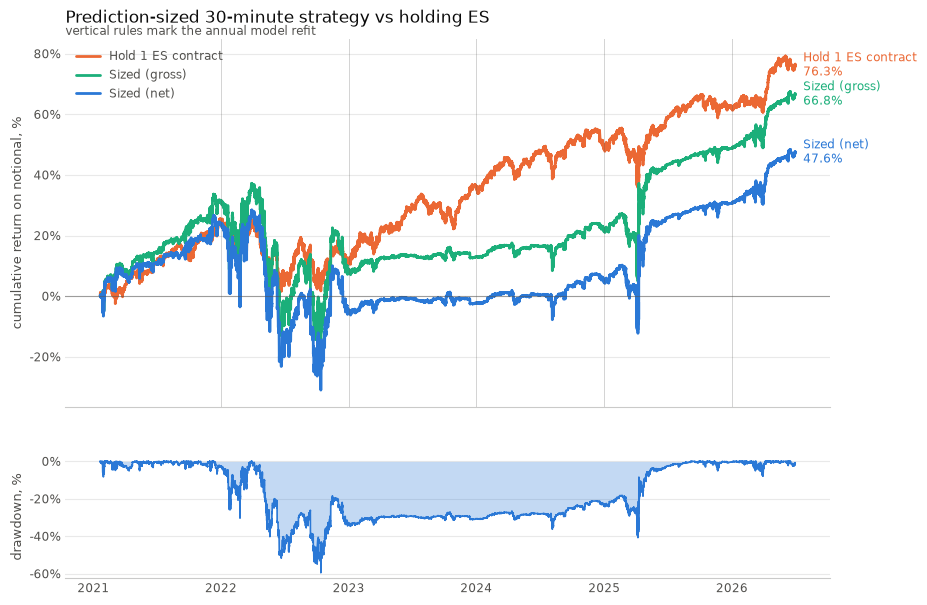

In [10]:
fig, (ax, ax_dd) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                height_ratios=[3, 1], facecolor="white")
curves = [("Hold 1 ES contract", 100 * (bt.pnl_hold / bt.notional).cumsum(), C_HOLD),
          ("Sized (gross)", 100 * (bt.pnl_gross / bt.notional).cumsum(), C_GROSS),
          ("Sized (net)", 100 * (bt.pnl_net / bt.notional).cumsum(), C_NET)]
for label, series, colour in curves:
    ax.plot(series.index, series.to_numpy(), color=colour, lw=2, label=label,
            solid_capstyle="round")
    ax.annotate(f"  {label}\n  {series.iloc[-1]:,.1f}%", xy=(series.index[-1], series.iloc[-1]),
                va="center", fontsize=8.5, color=colour, annotation_clip=False)
for year in sorted(bt.year.unique())[1:]:
    ax.axvline(pd.Timestamp(f"{year}-01-01", tz="UTC"), color=INK_MUTED, lw=0.7, alpha=0.25)
ax.axhline(0, color=INK_MUTED, lw=0.8, alpha=0.5)
ax.set_ylabel("cumulative return on notional, %", fontsize=9, color=INK_MUTED)
ax.set_title("Prediction-sized 30-minute strategy vs holding ES", fontsize=12,
             color=INK, pad=12, loc="left")
ax.text(0.0, 1.012, "vertical rules mark the annual model refit", transform=ax.transAxes,
        fontsize=8.5, color=INK_MUTED)
ax.legend(loc="upper left", frameon=False, fontsize=8.5, labelcolor=INK_MUTED)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}%")

dd = 100 * drawdown(bt.pnl_net / bt.notional)
ax_dd.fill_between(dd.index, dd.to_numpy(), 0, color=C_NET, alpha=0.28, linewidth=0)
ax_dd.plot(dd.index, dd.to_numpy(), color=C_NET, lw=1.2)
ax_dd.set_ylabel("drawdown, %", fontsize=9, color=INK_MUTED)
ax_dd.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}%")

for a in (ax, ax_dd):
    a.grid(axis="y", color=INK_MUTED, alpha=0.12, lw=0.8)
    a.set_axisbelow(True)
    for side in ("top", "right", "left"):
        a.spines[side].set_visible(False)
    a.spines["bottom"].set_color(INK_MUTED)
    a.spines["bottom"].set_alpha(0.3)
    a.tick_params(colors=INK_MUTED, labelsize=8.5, length=0)
fig.subplots_adjust(right=0.82)
plt.show()

**Findings: yes, it is largely a market play.**

Beta to the benchmark is **1.20** with a t-statistic of 292 and an R-squared of 0.59,
so nearly 60% of the strategy's variance is the index. Alpha is **not distinguishable
from zero** in either direction: +0.041 bps per bar gross (t = 0.64) and -0.044 net
(t = -0.68). Annualised that is +4.5% gross and -4.8% net, both inside the noise.

The binary version carries beta 0.74 and the same nil alpha. So the sizing rule did one
thing clearly: it raised market exposure from 0.74 to 1.20. The higher total return in
the table above is that beta, not a better signal.

Set against holding one contract, which returns 68.5% at Sharpe 0.774 with a 23.9%
drawdown, the sized strategy returns 56.3% at Sharpe 0.406 with a 48.0% drawdown. It
takes more risk, earns less, and what it does earn is the index.

It beat the benchmark in 3 years of 6, and the year-by-year pattern is wide: -27.3
points in 2023, +21.8 in 2025. That dispersion at beta 1.2 is what an unlevered index
position with noise on top looks like.